## Rx2day - AGCD

In [1]:
import glob

import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import numpy as np

from unseen import process_utils
from unseen import eva

In [2]:
ds = xr.open_dataset('/g/data/xv83/unseen-projects/outputs/pasha/data/rx2day_AGCD-CSIRO_1901-2024_A-AUG_pasha.nc')

In [3]:
# Drop first timestep due to rolling window
ds = ds.isel(time=slice(1, None))

In [4]:
ds

<xarray.Dataset> Size: 7kB
Dimensions:     (time: 122)
Coordinates:
  * time        (time) datetime64[ns] 976B 1902-08-31 1903-08-31 ... 2023-08-31
    event_time  (time) <U10 5kB ...
Data variables:
    pr          (time) float64 976B ...
Attributes: (12/33)
    CDI:                           Climate Data Interface version ?? (http://...
    history:                       Mon Sep 01 16:52:04 2025: /g/data/xv83/dbi...
    institution:                   Australian Bureau of Meteorology, GPO Box ...
    Conventions:                   CF-1.6
    geospatial_lat_min:            -44.525
    geospatial_lat_max:            -9.975
    ...                            ...
    url:                           http://www.bom.gov.au/climate/
    licence:                       Copyright for any data supplied by the Bur...
    id:                            Australian Gridded Climate Data (AGCD)
    summary:                       The daily and monthly rainfall data repres...
    naming_authority:              au.gov.bom
    CDO:                           Climate Data Operators version 1.7.0 (http...

In [5]:
df = ds.to_dataframe()
df.index = df.index.year

In [6]:
df

,pr,event_time
time,,
1902,55.836872,1901-10-11
1903,119.287933,1902-10-13
1904,157.892822,1904-07-10
1905,85.077652,1905-04-03
1906,103.985954,1906-08-31
...,...,...
2019,96.782570,2019-08-31
2020,152.609909,2020-02-09
2021,130.785706,2021-03-20


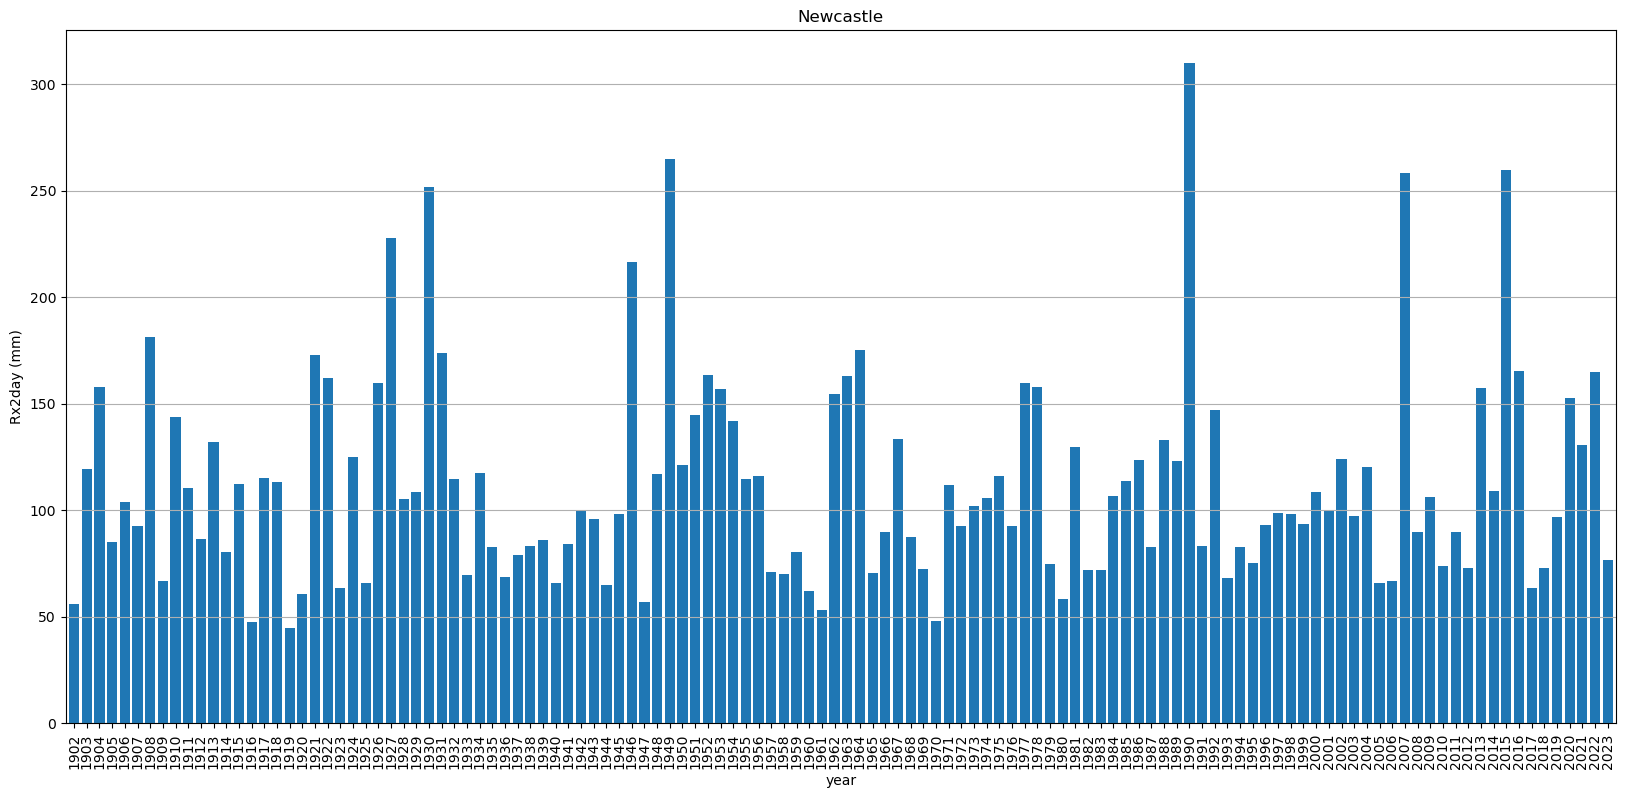

In [7]:
df['pr'].plot.bar(figsize=[20, 9], width=0.8)
plt.ylabel('Rx2day (mm)')
plt.xlabel('year')
plt.title('Newcastle')
plt.grid(axis='y')
plt.show()

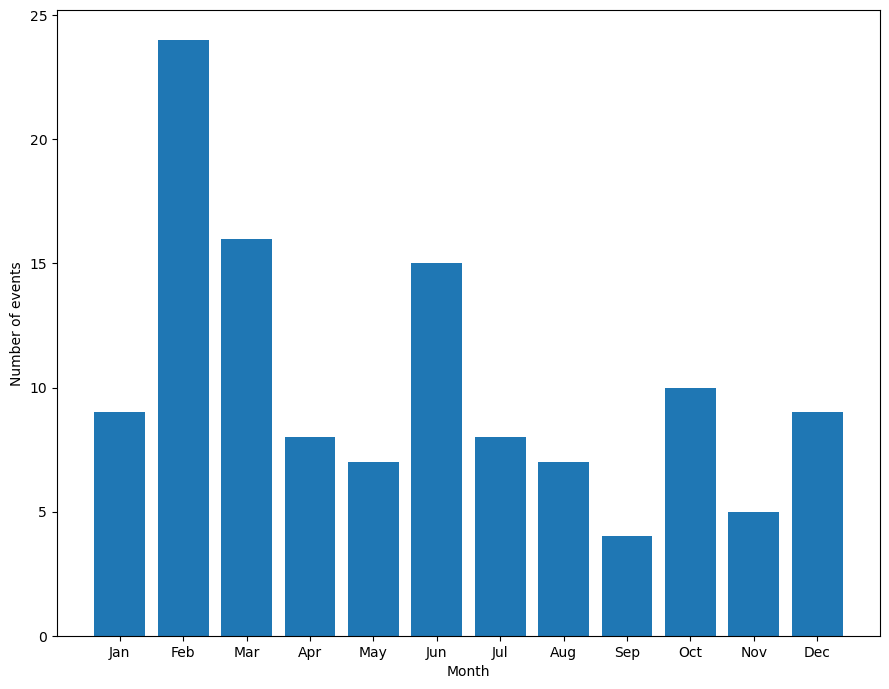

In [8]:
process_utils.plot_event_seasonality(ds, core_dim='time')

In [9]:
ranked_years = df.sort_values(by='pr', ascending=False)
print(ranked_years.head(n=10))

              pr  event_time
time                        
1990  309.776855  1990-02-04
1949  264.844543  1949-06-18
2015  259.481903  2015-04-22
2007  258.163055  2007-06-09
1930  251.686829  1930-06-18
1927  227.571899  1926-12-29
1946  216.690765  1946-04-17
1908  181.437012  1908-02-24
1964  175.244171  1964-06-11
1931  173.923019  1931-04-24


In [10]:
rx2day_2007 = ranked_years.iloc[3]['pr']

In [11]:
rx2day_2007

np.float64(258.1630554199219)

In [12]:
gev_shape, gev_loc, gev_scale = eva.fit_gev(ds['pr'].values)

49 year return period
95% CI: 25-185 years


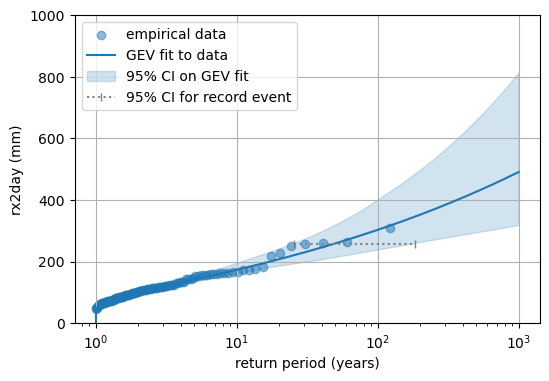

In [13]:
fig = plt.figure(figsize=[6, 4])
ax = fig.add_subplot()
eva.plot_gev_return_curve(
    ax,
    ds['pr'].values,
    rx2day_2007,
    direction="exceedance",
    bootstrap_method='parametric',
    n_bootstraps=100,
    max_return_period=3,
    ylabel='rx2day (mm)',
    ylim=(0, 1000),
)
plt.show()

In [14]:
shape, loc, scale = eva.fit_gev(ds['pr'].values)

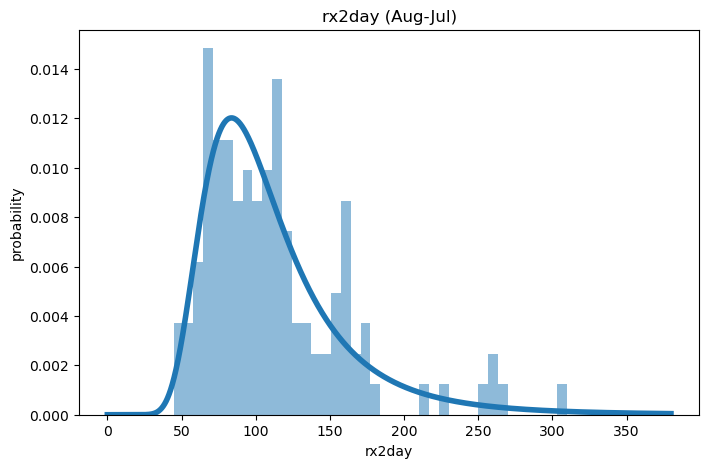

In [15]:
fig, ax = plt.subplots(figsize=[8, 5])
gev_xvals = np.arange(0, 380, 0.1)

ds['pr'].plot.hist(bins=40, density=True, color='tab:blue', alpha=0.5)
pdf = gev.pdf(gev_xvals, shape, loc, scale)
plt.plot(gev_xvals, pdf, color='tab:blue', linewidth=4.0, label='AGCD')

plt.xlabel('rx2day')
plt.ylabel('probability')
plt.title(f'rx2day (Aug-Jul)')
#plt.xlim(xmin, xmax)
plt.show()